In [1]:
import os
import deeptile
import matplotlib.pyplot as plt
import numpy as np
from deeptile.extensions import stitch
from tifffile import TiffFile
import tifffile
import dask.array as da
import utils
import skimage as ski
import importlib
import extract_features
import pandas as pd
from collections import defaultdict
from extract_features import features_basic, foci_features, feature_table, neighbor_measurements
from scipy import ndimage as ndi

In [ ]:
importlib.reload(utils)

In [10]:
root = "/Users/hannahbolen/Desktop/image_analysis/"
# img_name = 'o8p_day18_s22.tif'
# img_name = 'o8p_day18.vsi'
#img_name = "o8p_day24_s12.ome.tif"
img_name = "o8p_day7_s12.ome.tif"
img_path = os.path.join(root, img_name)
with tifffile.TiffFile(img_path) as tif:
    dt_nuclei = deeptile.load(tif.pages[0].asarray())
    dt_foci = deeptile.load(tif.pages[1].asarray())

In [32]:
# Configure
tile_size = (512, 512)
overlap = (0.1, 0.1)
# Get nuceli tiles
tiles_nuclei = dt_nuclei.get_tiles(tile_size, overlap)
tiles_nuclei = tiles_nuclei.pad()
# Get foci tiles
tiles_foci = dt_foci.get_tiles(tile_size, overlap)
tiles_foci = tiles_foci.pad()
# # Individual tile
# tiles_nuclei[0, 0]
# tiles_foci[0, 0]

In [33]:
# Segment tiles and stitch
model_parameters = {'gpu': True, 'model_type': 'nuclei'}
eval_parameters = {'diameter': 60}
cellpose = utils.cellpose_segmentation(model_parameters, eval_parameters)

masks_nuclei = cellpose(tiles_nuclei)
mask_nuclei = stitch.stitch_masks(masks_nuclei)

2026-03-16 20:20:26,655 [INFO] WRITING LOG OUTPUT TO /Users/hannahbolen/.cellpose/run.log
2026-03-16 20:20:26,655 [INFO] 
cellpose version: 	4.0.8 
platform:       	darwin 
python version: 	3.11.14 
torch version:  	2.9.1
2026-03-16 20:20:26,656 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2026-03-16 20:20:26,686 [INFO] ** TORCH MPS version installed and working. **
2026-03-16 20:20:26,686 [INFO] >>>> using GPU (MPS)
2026-03-16 20:20:27,286 [INFO] >>>> loading model /Users/hannahbolen/.cellpose/models/cpsam
2026-03-16 20:20:27,851 [INFO] processing grayscale image with (512, 512) HW
2026-03-16 20:20:29,104 [INFO] processing grayscale image with (512, 512) HW
2026-03-16 20:20:30,190 [INFO] processing grayscale image with (512, 512) HW
2026-03-16 20:20:31,284 [INFO] processing grayscale image with (512, 512) HW
2026-03-16 20:20:32,329 [INFO] No cell pixels found.
2026-03-16 20:20:32,344 [INFO] processing grayscale image with (512, 512) HW
2026-03-16 20:

In [ ]:
# mask_file = "".join([img_path.split(".")[0], "_MASK.tif"])
# nuclei_mask_fromTif = da.from_array(tifffile.imread(mask_file))
# img_foci = da.from_array(tifffile.imread(img_path))[1]
# #labeled_nuclei_fromtif = ski.measure.label(nuclei_mask_fromTif)
# save mask
# mask_file = "".join([img_path.split(".")[0], "_MASK.tif"])
# img_dtype = tifffile.TiffFile(img_path).pages[0].dtype
# tifffile.imwrite(mask_file, mask_nuclei.astype(img_dtype))

In [ ]:
show = ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(img_foci_ds, in_range=(0,3000)), labeled_maybe, color=(1,0,1))
#show = ski.color.label2rgb(labeled_maybe)
fig = px.imshow(show, binary_string=True)
fig.update_layout(
    autosize=False,
    width=1000,
    height=1000)
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
plotly.io.show(fig)

In [ ]:
# Show the nuclei tiles
fig, ax = plt.subplots(tiles_nuclei.shape[0], tiles_nuclei.shape[1], figsize=(10, 10))
for (i, j), tile in np.ndenumerate(tiles_nuclei):
    ax[i, j].imshow(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(tile, in_range=(0,6000)),masks_nuclei[i,j], color=(1,0,1), mode="thick"), cmap='gray')
    ax[i, j].set_xticks([])
    ax[i, j].set_yticks([])
plt.tight_layout()

In [ ]:
# Show the stitched mask
fig, ax = plt.subplots(figsize=(20, 20))
ax.imshow(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(dt_nuclei.image[::2,::2], in_range=(0,6000)), mask_nuclei[::2,::2], color=(1,0,1), mode="thick"), cmap='gray')
# ski.exposure.rescale_intensity(nucleiTile,in_range = (256, 12000))

In [47]:
## find foci
#importlib.reload(utils)
## make tiled nuclei mask with same profile as tiled foci
import_masks_nuclei = tiles_foci.import_data(mask_nuclei, "image").unpad().pad() # need to unpad, pad bc bug in package code
# segment foci and stitch
kwargs = {"radius":2, "threshold":25, "min_distance":1, "regions":import_masks_nuclei, "remove_border_foci":True}
masks_foci = utils.segment_foci_tiled(tiles_foci, **kwargs)
mask_foci = stitch.stitch_masks(masks_foci)


# save mask
mask_file = "".join([img_path.split(".")[0], "_FOCI_MASK.tif"])
img_dtype = tifffile.TiffFile(img_path).pages[0].dtype
tifffile.imwrite(mask_file, mask_nuclei.astype(img_dtype))

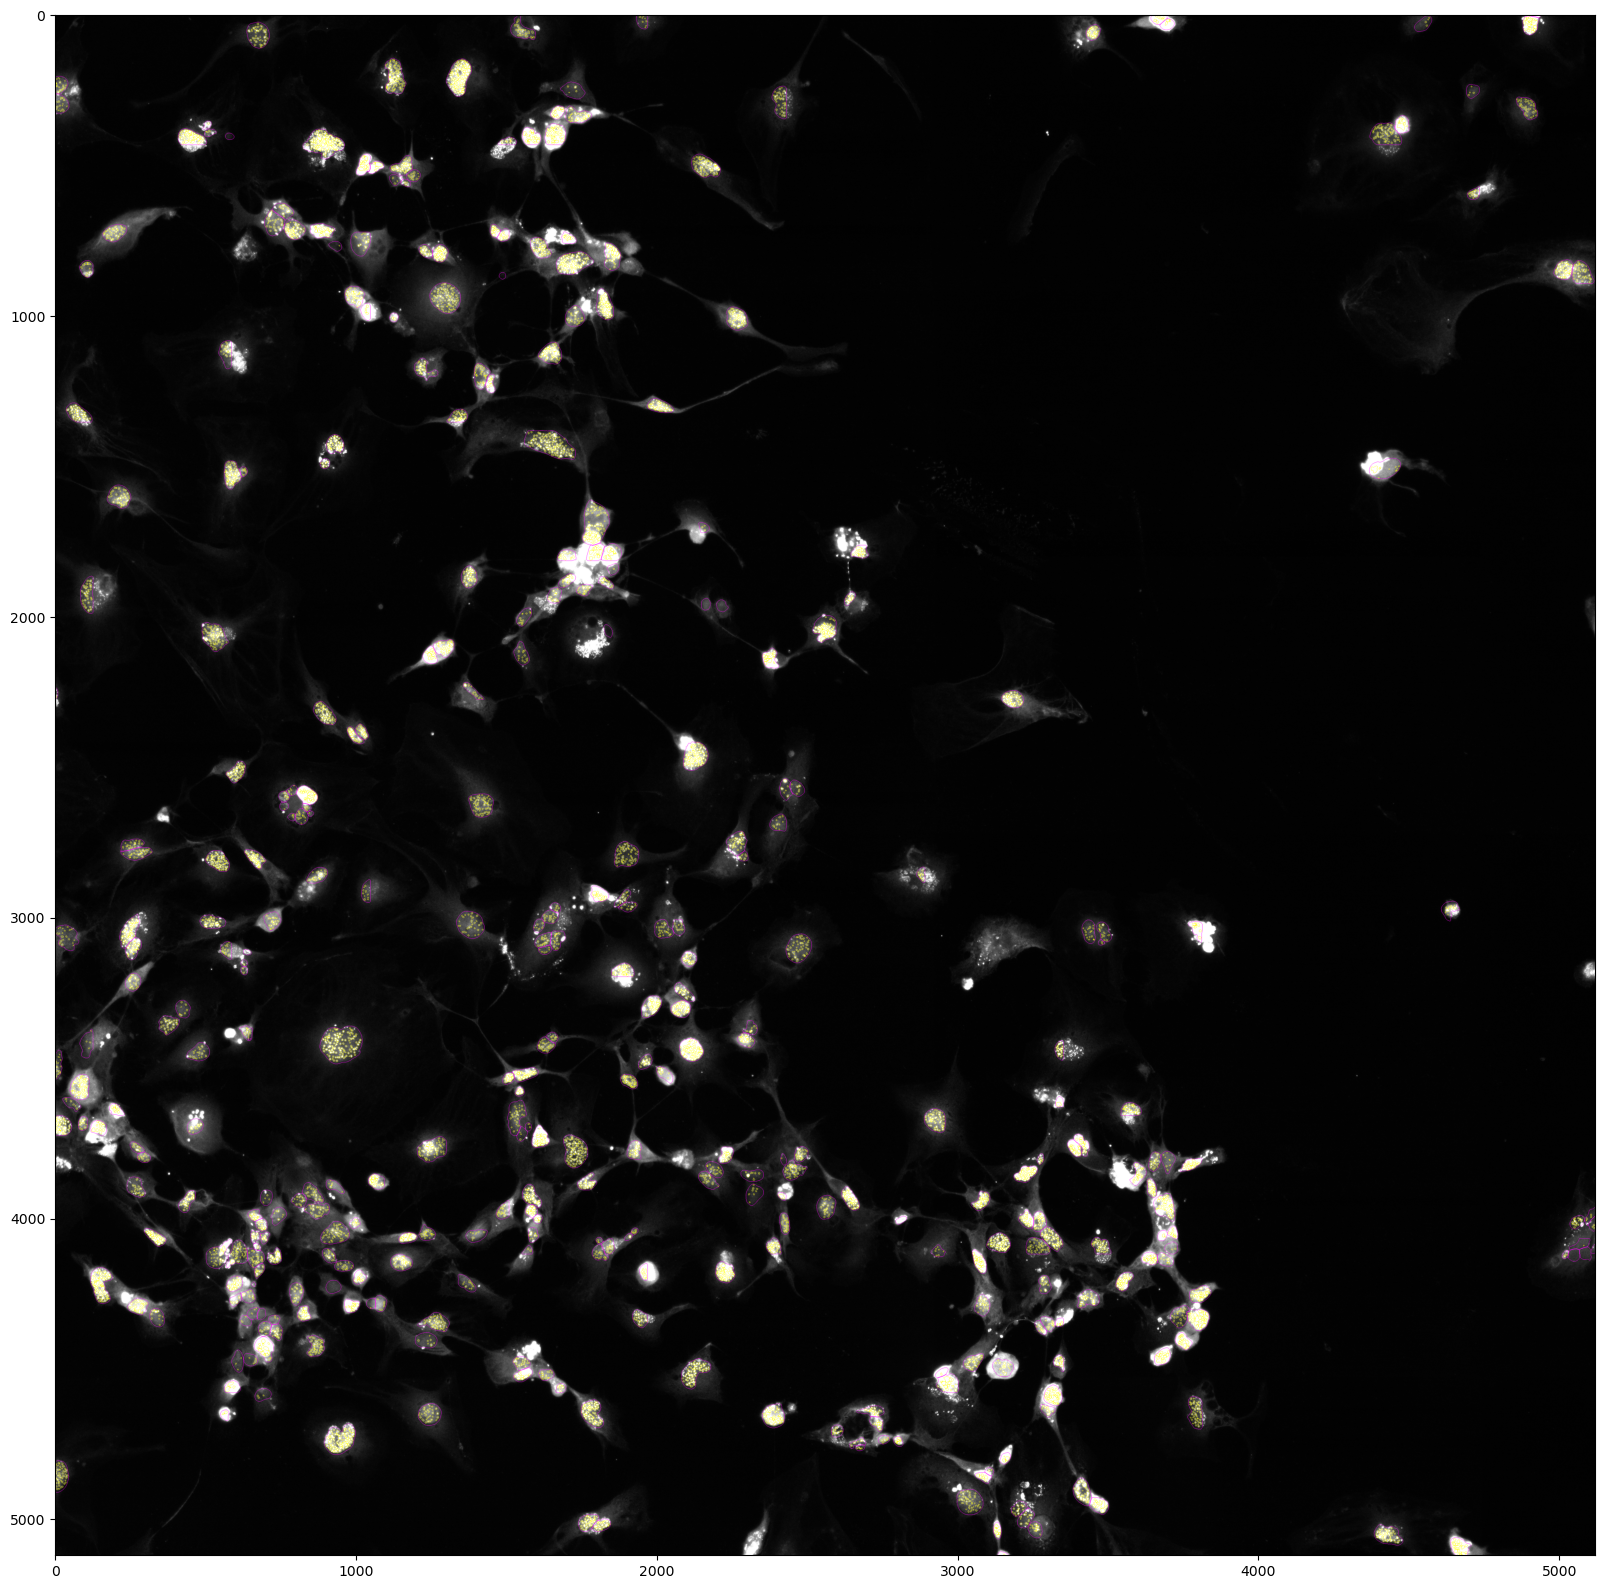

In [53]:
# Show the stitched mask
fig, ax = plt.subplots(figsize=(20, 20))
#ax[0].imshow(ski.color.label2rgb(foci_mask))
#ax[0].imshow(ski.exposure.rescale_intensity(dt.image, in_range=(256,3000)), cmap='gray')
h, w = dt_foci.image.shape
ax.imshow(ski.segmentation.mark_boundaries(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(dt_foci.image[h//2:h//2+5120,w//2-2000:w//2+5120-2000], in_range=(0,3000)), mask_foci[h//2:h//2+5120,w//2-2000:w//2+5120-2000]), mask_nuclei[h//2:h//2+5120,w//2-2000:w//2+5120-2000], color=(1,0,1)), cmap='gray')

In [48]:
dfs = []
dfs.append(
    feature_table(mask_nuclei, features_basic)
    .set_index("label")
    .add_prefix("nuclei_")
)

dfs.append(
    feature_table(mask_nuclei, foci_features, mask_foci)
    .set_index("label")
)

dfs.append(
    neighbor_measurements(mask_nuclei, distances=[1])
    .set_index("label")
    .add_prefix("nucleus_")
)

results_fullslide = pd.concat(dfs, axis=1, join="outer", sort=False).reset_index().set_index("label", drop=False)
results_fullslide.to_csv("".join([img_path.split(".")[0], ".csv"]))

/Users/hannahbolen/Desktop/image_analysis/whole_slide/deeptile_implement/extract_features.py:198: RuntimeWarning: invalid value encountered in arccos
  return np.arccos(cosine_angle)
